In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os
from backend import load_data, compute_optimal_weights_aversion, generate_efficient_frontier_data

In [2]:
prices, details = load_data("fund_prices.csv", "fund_detail.csv")

risk_aversion = [1.5, 2.5, 3.5, 6, 12]
code_to_name = details#.set_index('code')['fund_name'].to_dict()

In [ ]:
# with open("frontend.json", "r", encoding="utf-8") as file:
#     data = json.load(file)

# risk_aversion = data.get("risk_aversion", 0)
# print(risk_aversion)

prices_df, code_to_name = load_data('fund_prices.csv', 'fund_detail.csv')
returns_df = prices_df.pct_change().dropna()

3.2333333333333334


In [34]:
fund_list = prices.columns
returns = prices[fund_list].pct_change()
returns.isna().sum()

0P00006G2D.SI     706
0P00006ONO.SI     706
0P00000K03       1783
0P00009VQG.SI    1783
JAGCX               1
0P0001DK5T.SI    1783
0P000161I1       1783
0P0001NP7X.SI    1784
0P00019B21.HK    1784
PEBCX               1
dtype: int64

In [35]:
# weights_no_short = compute_optimal_weights(returns=returns_df, allow_short=False)
# weights_short = compute_optimal_weights(returns=returns_df, allow_short=True)
# print(weights_no_short)
# print(weights_short)
# print(weights_no_short.sum(), weights_short.sum())

In [ ]:
def compute_optimal_weights_aversion(risk_aversion,
                                    returns,
                                    allow_short=False,
                                    max_leverage=10):  # 添加最大杠杆参数
    """
    基于投资者对风险的厌恶程度计算最优投资组合权重（允许或不允许空头）。

    参数:
    risk_aversion (int): 风险厌恶系数
    returns (pd.DataFrame): 日收益率数据，时间 x 股票
    allow_short (bool): 是否允许空头，默认 False
    max_leverage (float): 最大允许的杠杆率

    返回:
    - weights_df (pd.DataFrame): 投资组合的最优权重
    """
    expected_returns = returns.mean().values * 252
    varcov = returns.cov().values * 252
    num_assets = len(expected_returns)

    def negative_utility(weights, risk_aversion):
        portfolio_return = np.dot(weights, expected_returns)          # r = w^T * R
        portfolio_variance = np.dot(weights.T, np.dot(varcov, weights))  # sigma^2 = w^T * VarCov * w
        utility = portfolio_return - (risk_aversion / 2) * portfolio_variance  # U = r - (A/2) * sigma^2
        return -utility  # 最小化 -U 等价于最大化 U
    
    # 创建约束条件列表
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]  # 权重和为1
    
    # 如果允许做空且设置了杠杆限制，添加杠杆约束
    if allow_short and max_leverage is not None:
        def leverage_constraint(weights):
            total_leverage = np.sum(np.abs(weights))
            return max_leverage - total_leverage  # 约束条件: 总杠杆 <= max_leverage
        
        constraints.append({'type': 'ineq', 'fun': leverage_constraint})
    
    # 设置边界条件
    if allow_short:
        bounds = None
    else:
        bounds = tuple((0, 1) for _ in range(num_assets))
    
    initial_guess = np.array([1.0 / num_assets] * num_assets)
    
    # 使用 minimize 优化
    result = minimize(
        fun=negative_utility,                # 目标函数
        x0=initial_guess,                    # 初始值
        args=(risk_aversion,),               # 传递风险厌恶系数
        bounds=bounds,                       # 边界条件
        constraints=constraints,             # 约束条件
        method='SLSQP'                       # 非线性优化方法，与 GRG Nonlinear 类似
    )

    if result.success:
        weights_df = pd.DataFrame(result.x, index=returns.columns, columns=[f"Weight_Aversion_{allow_short}"])
    else:
        raise ValueError("Optimization failed")
    return weights_df

In [ ]:
def generate_efficient_frontier_data(
        weights_no_short,
        weights_short,
        risk_aversion,
        returns, 
        code_to_name,
        filename=r"backend.json",
        max_leverage=10):  # 新增参数控制最大杠杆
    """
    参数:
    - weights_no_short (pd.DataFrame): 不允许空头的最优权重
    - weights_short (pd.DataFrame): 允许空头的最优权重
    - returns (pd.DataFrame): 日收益率数据
    - code_to_name (dict): 代码 -> 基金名称映射
    - filename (str): 输出文件路径
    - max_leverage (float): 允许的最大杠杆比率
    返回:
    - JSON 字符串，包含有效前沿数据和单个基金数据
    """
    # 计算年化收益和协方差矩阵
    expected_returns = returns.mean().values * 252
    varcov = returns.cov().values * 252
    num_assets = len(expected_returns)
    stock_risks = returns.std().values * np.sqrt(252)
    target_min = np.min(expected_returns)-2
    target_max = np.max(expected_returns)+2
    # 生成目标收益率范围
    target_returns = np.linspace(target_min, target_max, 100)
    
    # 定义杠杆约束函数
    def leverage_constraint(weights, max_lev=max_leverage):
        total_leverage = np.sum(np.abs(weights))
        return max_lev - total_leverage  # 约束条件: 总杠杆 <= max_leverage
    
    def compute_frontier(allow_short):
        portfolio_risks = []
        valid_target_returns = []
        for target in target_returns:
            # 基本约束条件
            constraints = [
                {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'eq', 'fun': lambda w: np.dot(w, expected_returns) - target}
            ]
            
            # 如果允许做空，添加杠杆约束
            if allow_short:
                constraints.append({'type': 'ineq', 'fun': leverage_constraint})
                bounds = None  # 允许空头
            else:
                bounds = tuple((0, 1) for _ in range(num_assets))  # 不允许空头
            
            initial_guess = np.array([1.0 / num_assets] * num_assets)
            result = minimize(lambda w: np.dot(w.T, np.dot(varcov, w)),
                              initial_guess, bounds=bounds, constraints=constraints)
            if result.success:
                portfolio_risks.append(np.sqrt(result.fun))
                valid_target_returns.append(target)
        return [{"risk": r, "return": ret} for r, ret in zip(portfolio_risks, valid_target_returns)]
    
    if not os.path.exists(filename):
        # 计算有效前沿数据
        efficient_frontier_no_short = compute_frontier(allow_short=False)
        efficient_frontier_short = compute_frontier(allow_short=True)
        chart_data = {
            "efficient_frontier_no_short": efficient_frontier_no_short,
            "efficient_frontier_short": efficient_frontier_short,
            "funds": [{"name": code_to_name.get(code, code), "risk": stock_risks[i], "return": expected_returns[i]}
                      for i, code in enumerate(returns.columns)],
        }
        
        # 保存JSON数据到文件
        with open(filename, "w") as f:
            json.dump(chart_data, indent=4, fp=f)
    else:
        with open(filename, "r") as f:
            chart_data = json.load(f)
            
    # 根据权重计算最优投资组合return和risk
    weights_no_short_df = compute_optimal_weights_aversion(
    risk_aversion=risk_aversion,
    returns=returns,
    allow_short=False
    )

    weights_short_df = compute_optimal_weights_aversion(
        risk_aversion=risk_aversion,
        returns=returns,
        allow_short=True
    )

    # 根据权重计算最优投资组合return和risk
    optimal_weights_no_short = weights_no_short_df.values.flatten()
    optimal_weights_short = weights_short_df.values.flatten()
    # optimal_weights_no_short = weights_no_short.values.flatten()
    # optimal_weights_short = weights_short.values.flatten()
    optimal_return_no_short = np.dot(optimal_weights_no_short, expected_returns)
    optimal_return_short = np.dot(optimal_weights_short, expected_returns)
    optimal_risk_no_short = np.sqrt(np.dot(optimal_weights_no_short.T, np.dot(varcov, optimal_weights_no_short)))
    optimal_risk_short = np.sqrt(np.dot(optimal_weights_short.T, np.dot(varcov, optimal_weights_short)))
    chart_data["optimal_portfolio"] = [
        {"name": "No Short", "risk": optimal_risk_no_short, "return": optimal_return_no_short},
        {"name": "Short", "risk": optimal_risk_short, "return": optimal_return_short}
    ]
    
    return json.dumps(chart_data, indent=4)

In [81]:
with open("frontend.json", "r", encoding="utf-8") as file:
    data = json.load(file)

risk_aversion = data.get("risk_aversion", 0)
print(risk_aversion)

3.2333333333333334


In [82]:
risk_aversion=10

In [83]:
weights_aversion_no_short = compute_optimal_weights_aversion(
    risk_aversion=risk_aversion,
    returns=returns,
    allow_short=False
)

weights_aversion_short = compute_optimal_weights_aversion(
    risk_aversion=risk_aversion,
    returns=returns,
    allow_short=True
)

print(weights_aversion_no_short)
print(weights_aversion_short)
print(weights_aversion_no_short.sum(), weights_aversion_short.sum())

leverage_no_short = np.sum(np.abs(weights_aversion_no_short.values))
leverage_short = np.sum(np.abs(weights_aversion_short.values))

max_leverage = 1
print(f"无做空的杠杆使用: {leverage_no_short}")
print(f"允许做空的杠杆使用: {leverage_short}")
print(f"杠杆限制: {max_leverage}")


               Weight_Aversion_False
0P00006G2D.SI           1.394124e-01
0P00006ONO.SI           5.006304e-17
0P00000K03              2.411355e-01
0P00009VQG.SI           0.000000e+00
JAGCX                   2.188408e-01
0P0001DK5T.SI           8.750733e-02
0P000161I1              0.000000e+00
0P0001NP7X.SI           0.000000e+00
0P00019B21.HK           2.644776e-17
PEBCX                   3.131040e-01
               Weight_Aversion_True
0P00006G2D.SI              0.403965
0P00006ONO.SI             -0.501479
0P00000K03                 0.316655
0P00009VQG.SI              0.122270
JAGCX                      0.311533
0P0001DK5T.SI             -0.048524
0P000161I1                -0.339695
0P0001NP7X.SI              0.184300
0P00019B21.HK             -0.294308
PEBCX                      0.845283
Weight_Aversion_False    1.0
dtype: float64 Weight_Aversion_True    1.0
dtype: float64
无做空的杠杆使用: 1.0000000000000002
允许做空的杠杆使用: 3.3680129815401867
杠杆限制: 1


In [84]:
filename = os.path.join("./", "backend.json")
chart_json = generate_efficient_frontier_data(
    weights_aversion_no_short, weights_aversion_short,
    risk_aversion,
    returns_df, code_to_name)

with open(filename, 'w', encoding='utf-8') as f:
    f.write(chart_json)

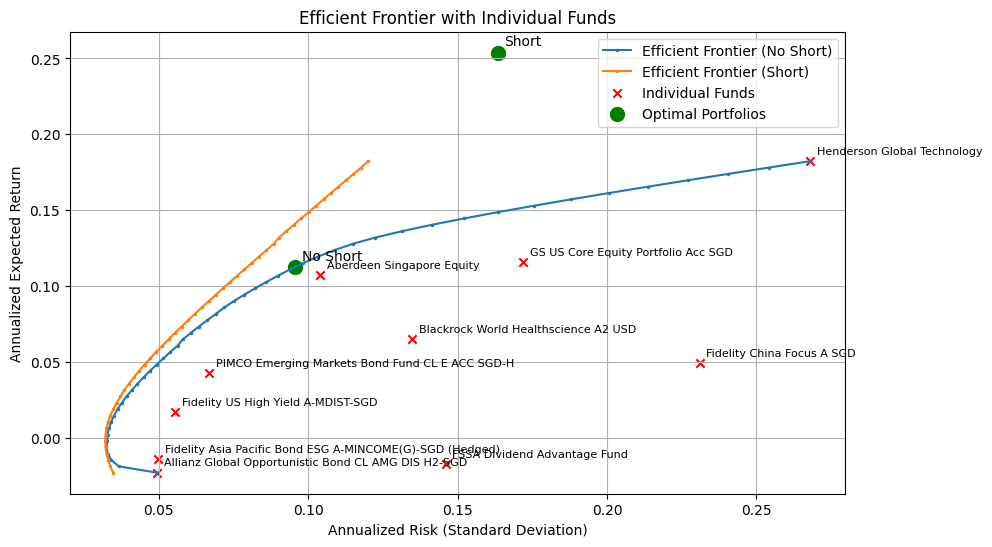

In [ ]:

with open("backend.json", "r") as f:
    chart_data = json.load(f)

plt.figure(figsize=(10, 6))

# 绘制不允许空头的有效前沿
ef_no_short = chart_data["efficient_frontier_no_short"]
risks_no_short = [point["risk"] for point in ef_no_short]
returns_no_short = [point["return"] for point in ef_no_short]
plt.plot(risks_no_short, returns_no_short, marker='.', markersize=3, label='Efficient Frontier (No Short)')

# 绘制允许空头的有效前沿
ef_short = chart_data["efficient_frontier_short"]
risks_short = [point["risk"] for point in ef_short]
returns_short = [point["return"] for point in ef_short]
plt.plot(risks_short, returns_short, marker='.', markersize=3, label='Efficient Frontier (Short)')

# 绘制单个基金的散点图
funds = chart_data["funds"]
fund_risks = [fund["risk"] for fund in funds]
fund_returns = [fund["return"] for fund in funds]
fund_names = [fund["name"] for fund in funds]
plt.scatter(fund_risks, fund_returns, color='red', marker='x', label='Individual Funds')

# 标注基金名称
for i, name in enumerate(fund_names):
    plt.annotate(name, (fund_risks[i], fund_returns[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

# 绘制最优投资组合点
optimal_portfolios = chart_data["optimal_portfolio"]
optimal_risks = [port["risk"] for port in optimal_portfolios]
optimal_returns = [port["return"] for port in optimal_portfolios]
optimal_names = [port["name"] for port in optimal_portfolios]
plt.scatter(optimal_risks, optimal_returns, color='green', marker='o', s=100, label='Optimal Portfolios')

# 标注最优投资组合
for i, name in enumerate(optimal_names):
    plt.annotate(name, (optimal_risks[i], optimal_returns[i]), fontsize=10, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Annualized Risk (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.title('Efficient Frontier with Individual Funds')
plt.legend()
plt.grid(True)
plt.show()